In [25]:
#imports
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
import seaborn as sns
import matplotlib.pyplot as plt
#load data
clean_df = pd.read_csv('/Users/colinclapper/Desktop/hiv-resistance-predictor/hiv-resistance-predictor/data/processed/nfv_clean.csv')

In [26]:
p_columns = [f'P{i}' for i in range(1, 100)]
feature_df = (clean_df[p_columns] != '-').astype(int)

X = feature_df
y = clean_df['resistance']

#sanity check before splitting the data
print(X.shape, y.shape)

(1903, 99) (1903,)


In [27]:
#setup train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(1522, 99) (381, 99)
resistance
1    0.542707
0    0.457293
Name: proportion, dtype: float64
resistance
1    0.543307
0    0.456693
Name: proportion, dtype: float64


In [28]:
#Create model object
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)
predictions = model.predict(X_test)

In [29]:
#Evaluate predictions against the real test labels
accuracy = (accuracy_score(y_test, predictions))
print(f"Accuracy of the model: {accuracy * 100:.2f}%")

Accuracy of the model: 95.28%


In [30]:
print(confusion_matrix(y_test, predictions))
print(classification_report(y_test, predictions))

[[164  10]
 [  8 199]]
              precision    recall  f1-score   support

           0       0.95      0.94      0.95       174
           1       0.95      0.96      0.96       207

    accuracy                           0.95       381
   macro avg       0.95      0.95      0.95       381
weighted avg       0.95      0.95      0.95       381



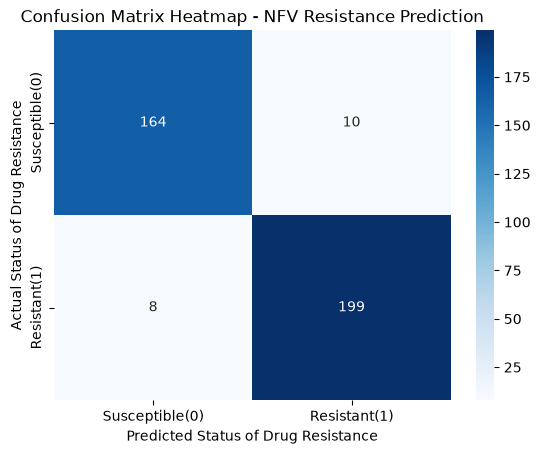

In [39]:
#make heatmap of confusion matrix using seaborn and matplotlib
cm = confusion_matrix(y_test, predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Susceptible(0)', 'Resistant(1)'],
            yticklabels=['Susceptible(0)', 'Resistant(1)'])
plt.xlabel('Predicted Status of Drug Resistance')
plt.ylabel('Actual Status of Drug Resistance')
plt.title('Confusion Matrix Heatmap - NFV Resistance Prediction')
#export heatmap as a png file
plt.savefig('/Users/colinclapper/Desktop/hiv-resistance-predictor/hiv-resistance-predictor/results/figures/confusion_matrix_heatmap.png')
plt.show()


In [33]:
#find out which mutations are most important for predicting resistance by looking at the coefficients of the logistic regression model
importance_df = pd.DataFrame({
    'position': X_train.columns,
    'coefficient': model.coef_[0]
}).sort_values(by='coefficient', ascending=False)

print(importance_df.head(10))

   position  coefficient
29      P30     3.732632
87      P88     3.083716
89      P90     2.131170
45      P46     2.016421
53      P54     1.886228
23      P24     1.877282
83      P84     1.569431
81      P82     1.467917
47      P48     1.365914
73      P74     1.227236


In [40]:
#Save reusults to csv for future use
report_dict = classification_report(y_test, predictions, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()
report_df.to_csv("/Users/colinclapper/Desktop/hiv-resistance-predictor/hiv-resistance-predictor/results/classification_report.csv")